In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py

In [2]:
target_d_L = 75.4#Mpc

In [3]:
base = "IPTA_MDC2_G2D1_narrow_UL_dL_75.4_"
crnr_plt_title1 =base+'corner plot_all_params'
crnr_plt_title2 =base
trace_plot_title = base+'trace_plot'
BF_histogram_title = base+'log10A_histogram'
BFerr_title = base+'log10A_histogram_error'

In [4]:
pwd

'/scratch/na00078/projects/IPTA_MDC2/post_processing'

## Generate Outfile

## Run Outfile

In [5]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_narrow_UL_fixed_gamma_outfile.h5"
infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_narrow_UL_fixed_gamma_outfile.h5
8
(10000000, 8)
(1, 10000000)


## Corner Plots

In [6]:
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}


xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:




hamp [4.4560749e-17 6.5106076e-17 5.4758190e-18 ... 1.3827001e-17 2.2531438e-18
 2.8410245e-15]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [8.5411930e+10 6.7056636e+10 1.6533062e+10 ... 7.7759554e+10 7.7759554e+10
 7.7759554e+10]
Length of logdL 10000000
required values 8.48491 3.7000025e-09 34449265000.0 7.202051e-16
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [5.2846560e+06 2.4166832e+06 2.7855532e+06 ... 1.4564633e+07 8.9379744e+07
 7.0884789e+04]
min 10**log10_d_L 0.0034446048
max 10**log10_d_L 305428830.0
d_L_mask [  24208   24585   27972   75978   89392   89394  122143  122344  122485
  122842  152126  153987  212672  267267  277696  288652  288940  303570
  303659  303944  350215  382821  383015  383188  384487  384575  426072
  446748  451541  490522  555342  556267  585072  594278  599813  683047
  745848  760028  761626  791838  810763  810787  822806  844630  845060
  845690  853187  853842  856221  856222  856

notd_L_mask2 [      0       1       2 ... 9999997 9999998 9999999]
merged_non_dL [   1274    2440    2859 ... 9999997 9999998 9999999]


Sample shape (10000000, 9)
dL_mask length 974
5
Max Mc sampled 9.891458


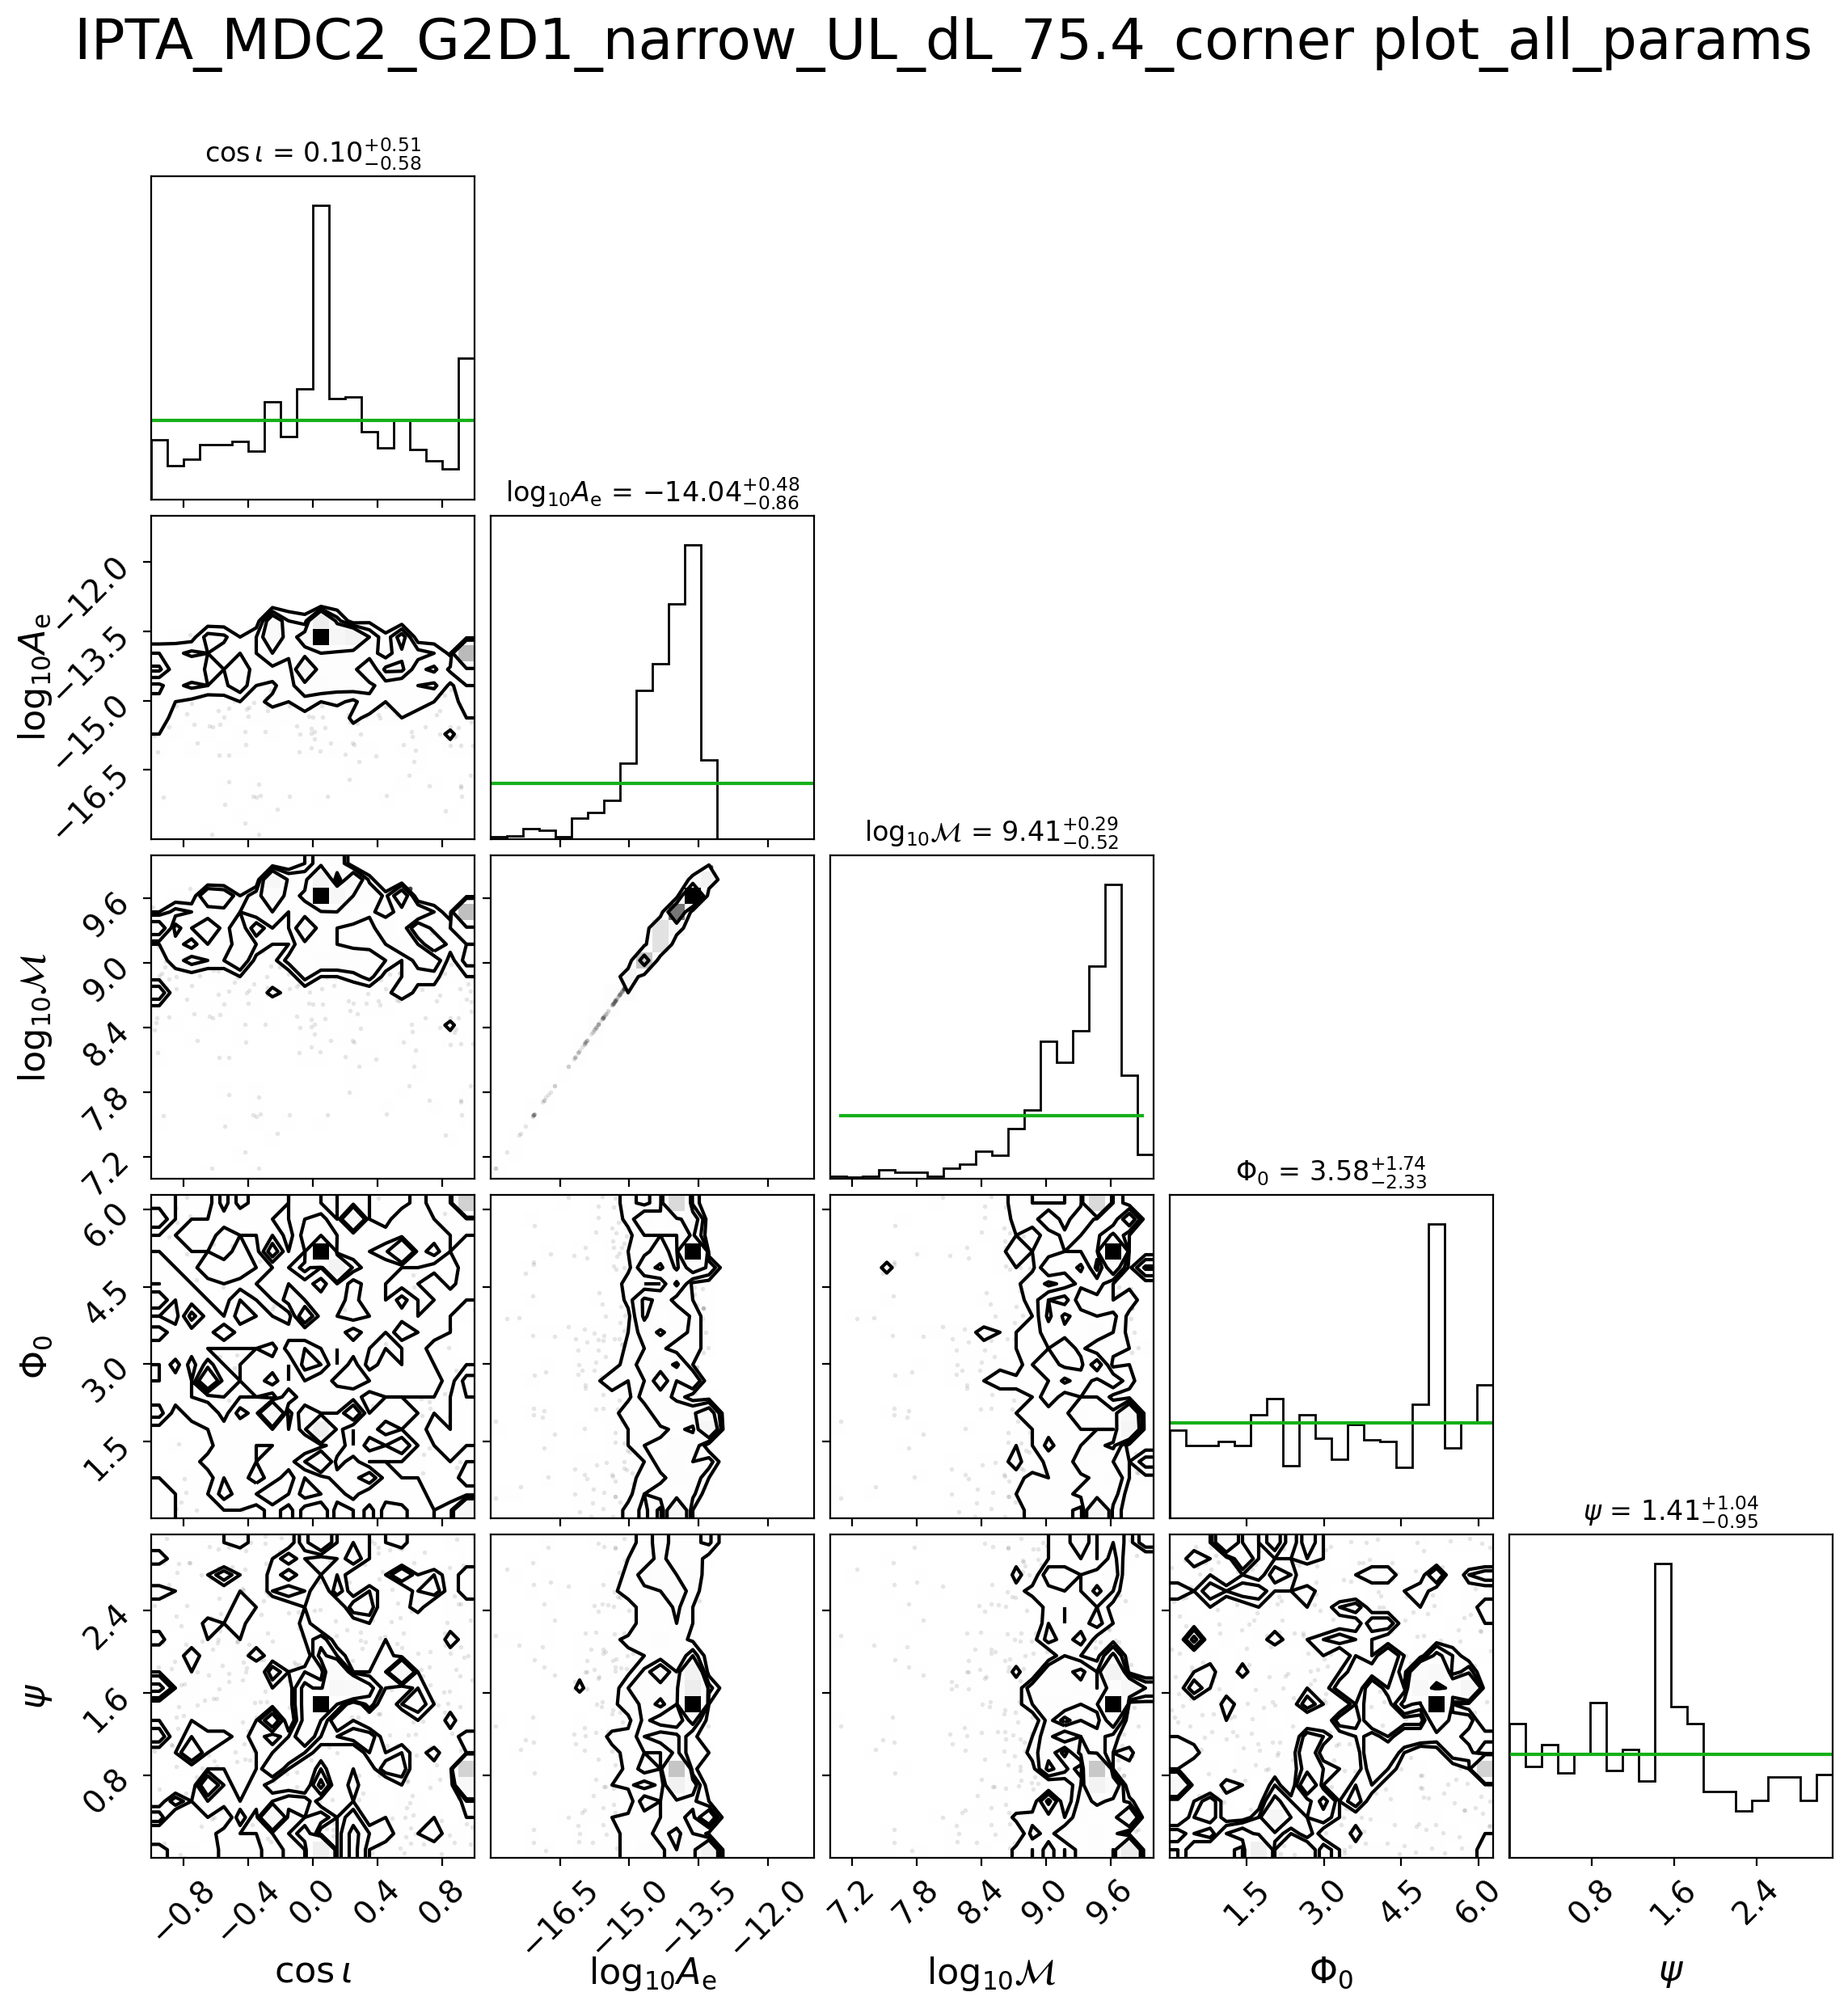

In [7]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-18,-11), (7,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True})
    #truths=truths,
    #truth_color="red"   # optional, highlights them in red)

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    #elif i==3*(len(labels)+1): #log10_fgw
     #   Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
      #  ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==3*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==4*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

Text(0.5, 1.05, 'IPTA_MDC2_G2D1_narrow_UL_dL_75.4_corner plot_all_params')

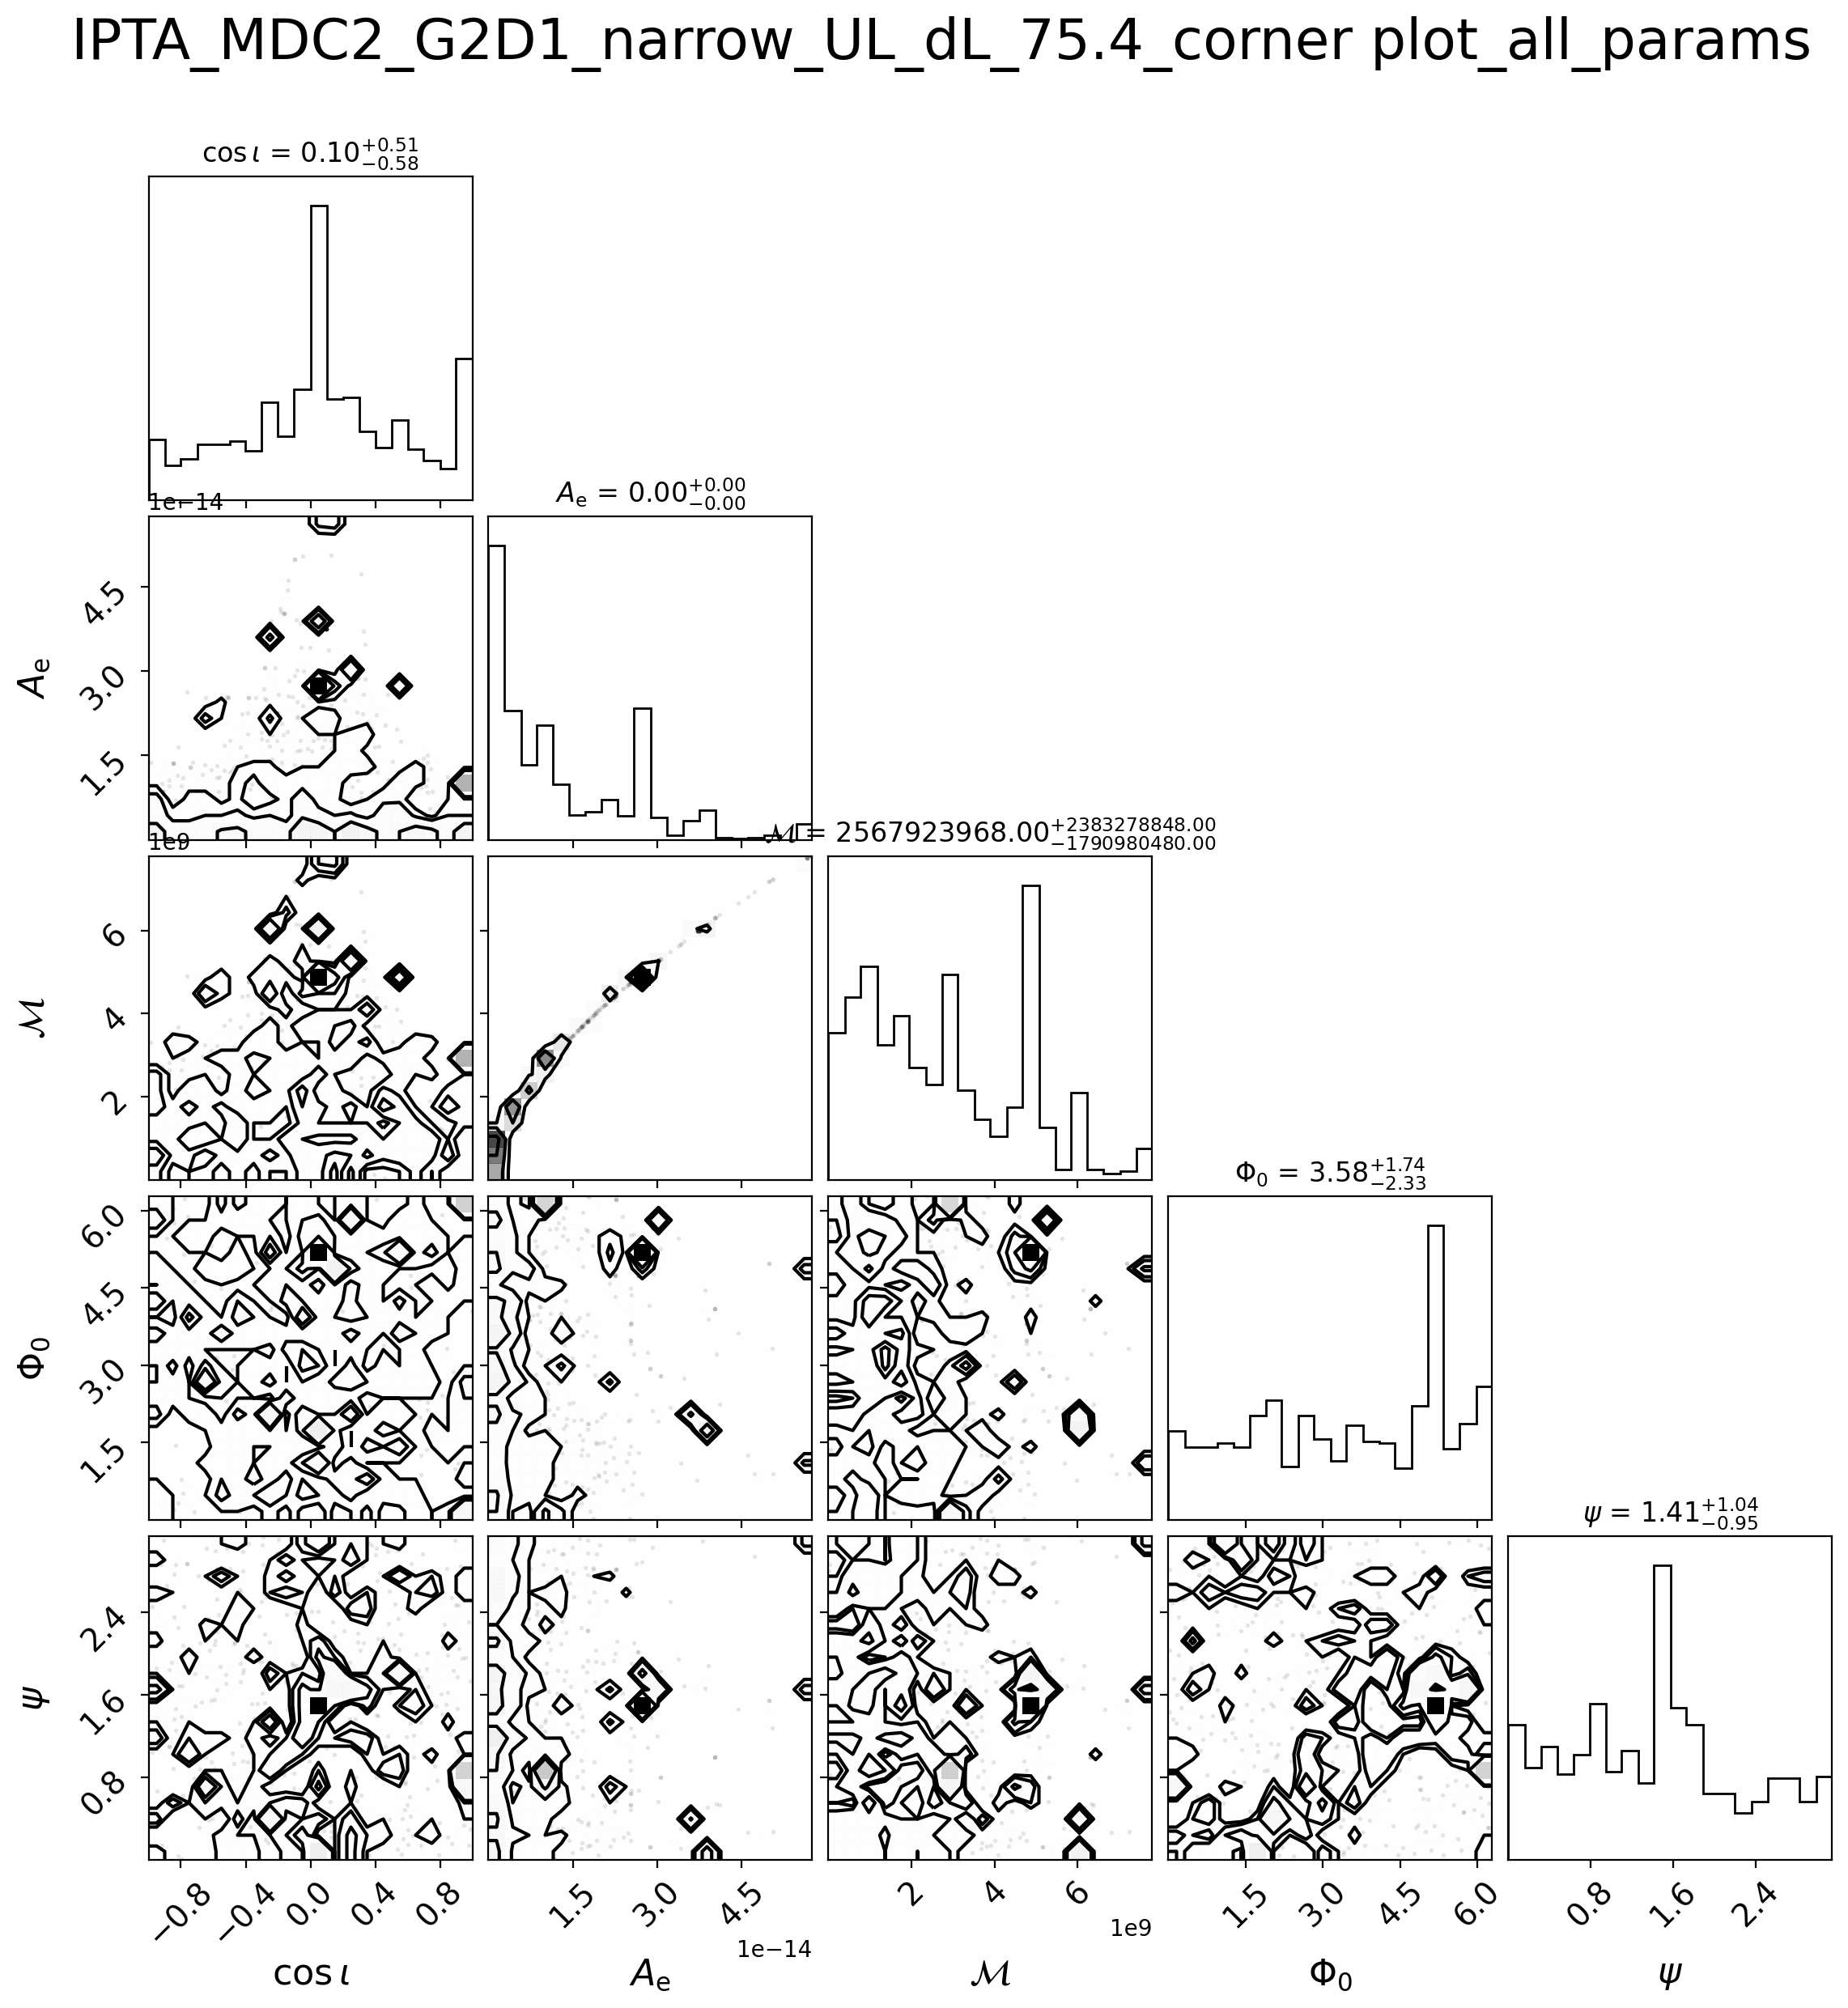

In [8]:
import numpy as np
import corner

# Labels: linear amplitude + linear chirp mass now
labels = [r"$\cos \iota$", r"$A_{\rm e}$", r"${\cal M}$", r"$\Phi_0$", r"$\psi$"]

# Burn-in/thin
burnin = 0
thin = 1

# Extract raw samples
h_amp = 10**samples_cold[0][burnin::thin,4]   # amplitude in linear
fff    = 10**samples_cold[0][burnin::thin,3]  # frequency (log->linear, not used here)
mmm    = 10**samples_cold[0][burnin::thin,5]  # chirp mass in linear

# Derived d_L (log)
log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp * speed_of_light/megaparsec)

# Build full samples with linear Mc and h_amp
samples2plot = np.concatenate(
    (samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L]).T),
    axis=1
)

# Replace log10_h and log10_mc columns with linear versions
samples2plot[:,4] = h_amp   # amplitude in linear
samples2plot[:,5] = mmm     # chirp mass in linear

# Mask by dL as before
d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]

# Select subset for plotting
samples2plot_detect = np.vstack((
    samples2plot[d_L_mask,1],   # cos i
    samples2plot[d_L_mask,4],   # amplitude (linear)
    samples2plot[d_L_mask,5],   # Mc (linear)
    samples2plot[d_L_mask,6],   # phase
    samples2plot[d_L_mask,7]    # psi
)).T

# Update ranges for linear quantities
ranges = [
    (-1, 1),                                  # cos i
    (np.min(h_amp[d_L_mask]), np.max(h_amp[d_L_mask])),  # amplitude
    (np.min(mmm[d_L_mask]),   np.max(mmm[d_L_mask])),    # chirp mass
    (0, 2*np.pi),                             # phase
    (0, np.pi)                                # psi
]

# Corner plot
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True}
)

# Increase font sizes
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

fig.suptitle(crnr_plt_title1, fontsize=25, y=1.05)


hamp [4.4560749e-17 6.5106076e-17 5.4758190e-18 ... 1.3827001e-17 2.2531438e-18
 2.8410245e-15]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [8.5411930e+10 6.7056636e+10 1.6533062e+10 ... 7.7759554e+10 7.7759554e+10
 7.7759554e+10]
Length of logdL 10000000
required values 8.48491e+00 3.7000025e-09 34449265000.0 7.202051e-16
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [5.2846560e+06 2.4166832e+06 2.7855532e+06 ... 1.4564633e+07 8.9379744e+07
 7.0884789e+04]
min 10**log10_d_L 0.0034446048
max 10**log10_d_L 305428830.0
d_L_mask [  24208   24585   27972   75978   89392   89394  122143  122344  122485
  122842  152126  153987  212672  267267  277696  288652  288940  303570
  303659  303944  350215  382821  383015  383188  384487  384575  426072
  446748  451541  490522  555342  556267  585072  594278  599813  683047
  745848  760028  761626  791838  810763  810787  822806  844630  845060
  845690  853187  853842  856221  856222 

notd_L_mask2 [      0       1       2 ... 9999997 9999998 9999999]
merged_non_dL [   1274    2440    2859 ... 9999997 9999998 9999999]
Sample shape (10000000, 9)
dL_mask length 974
9


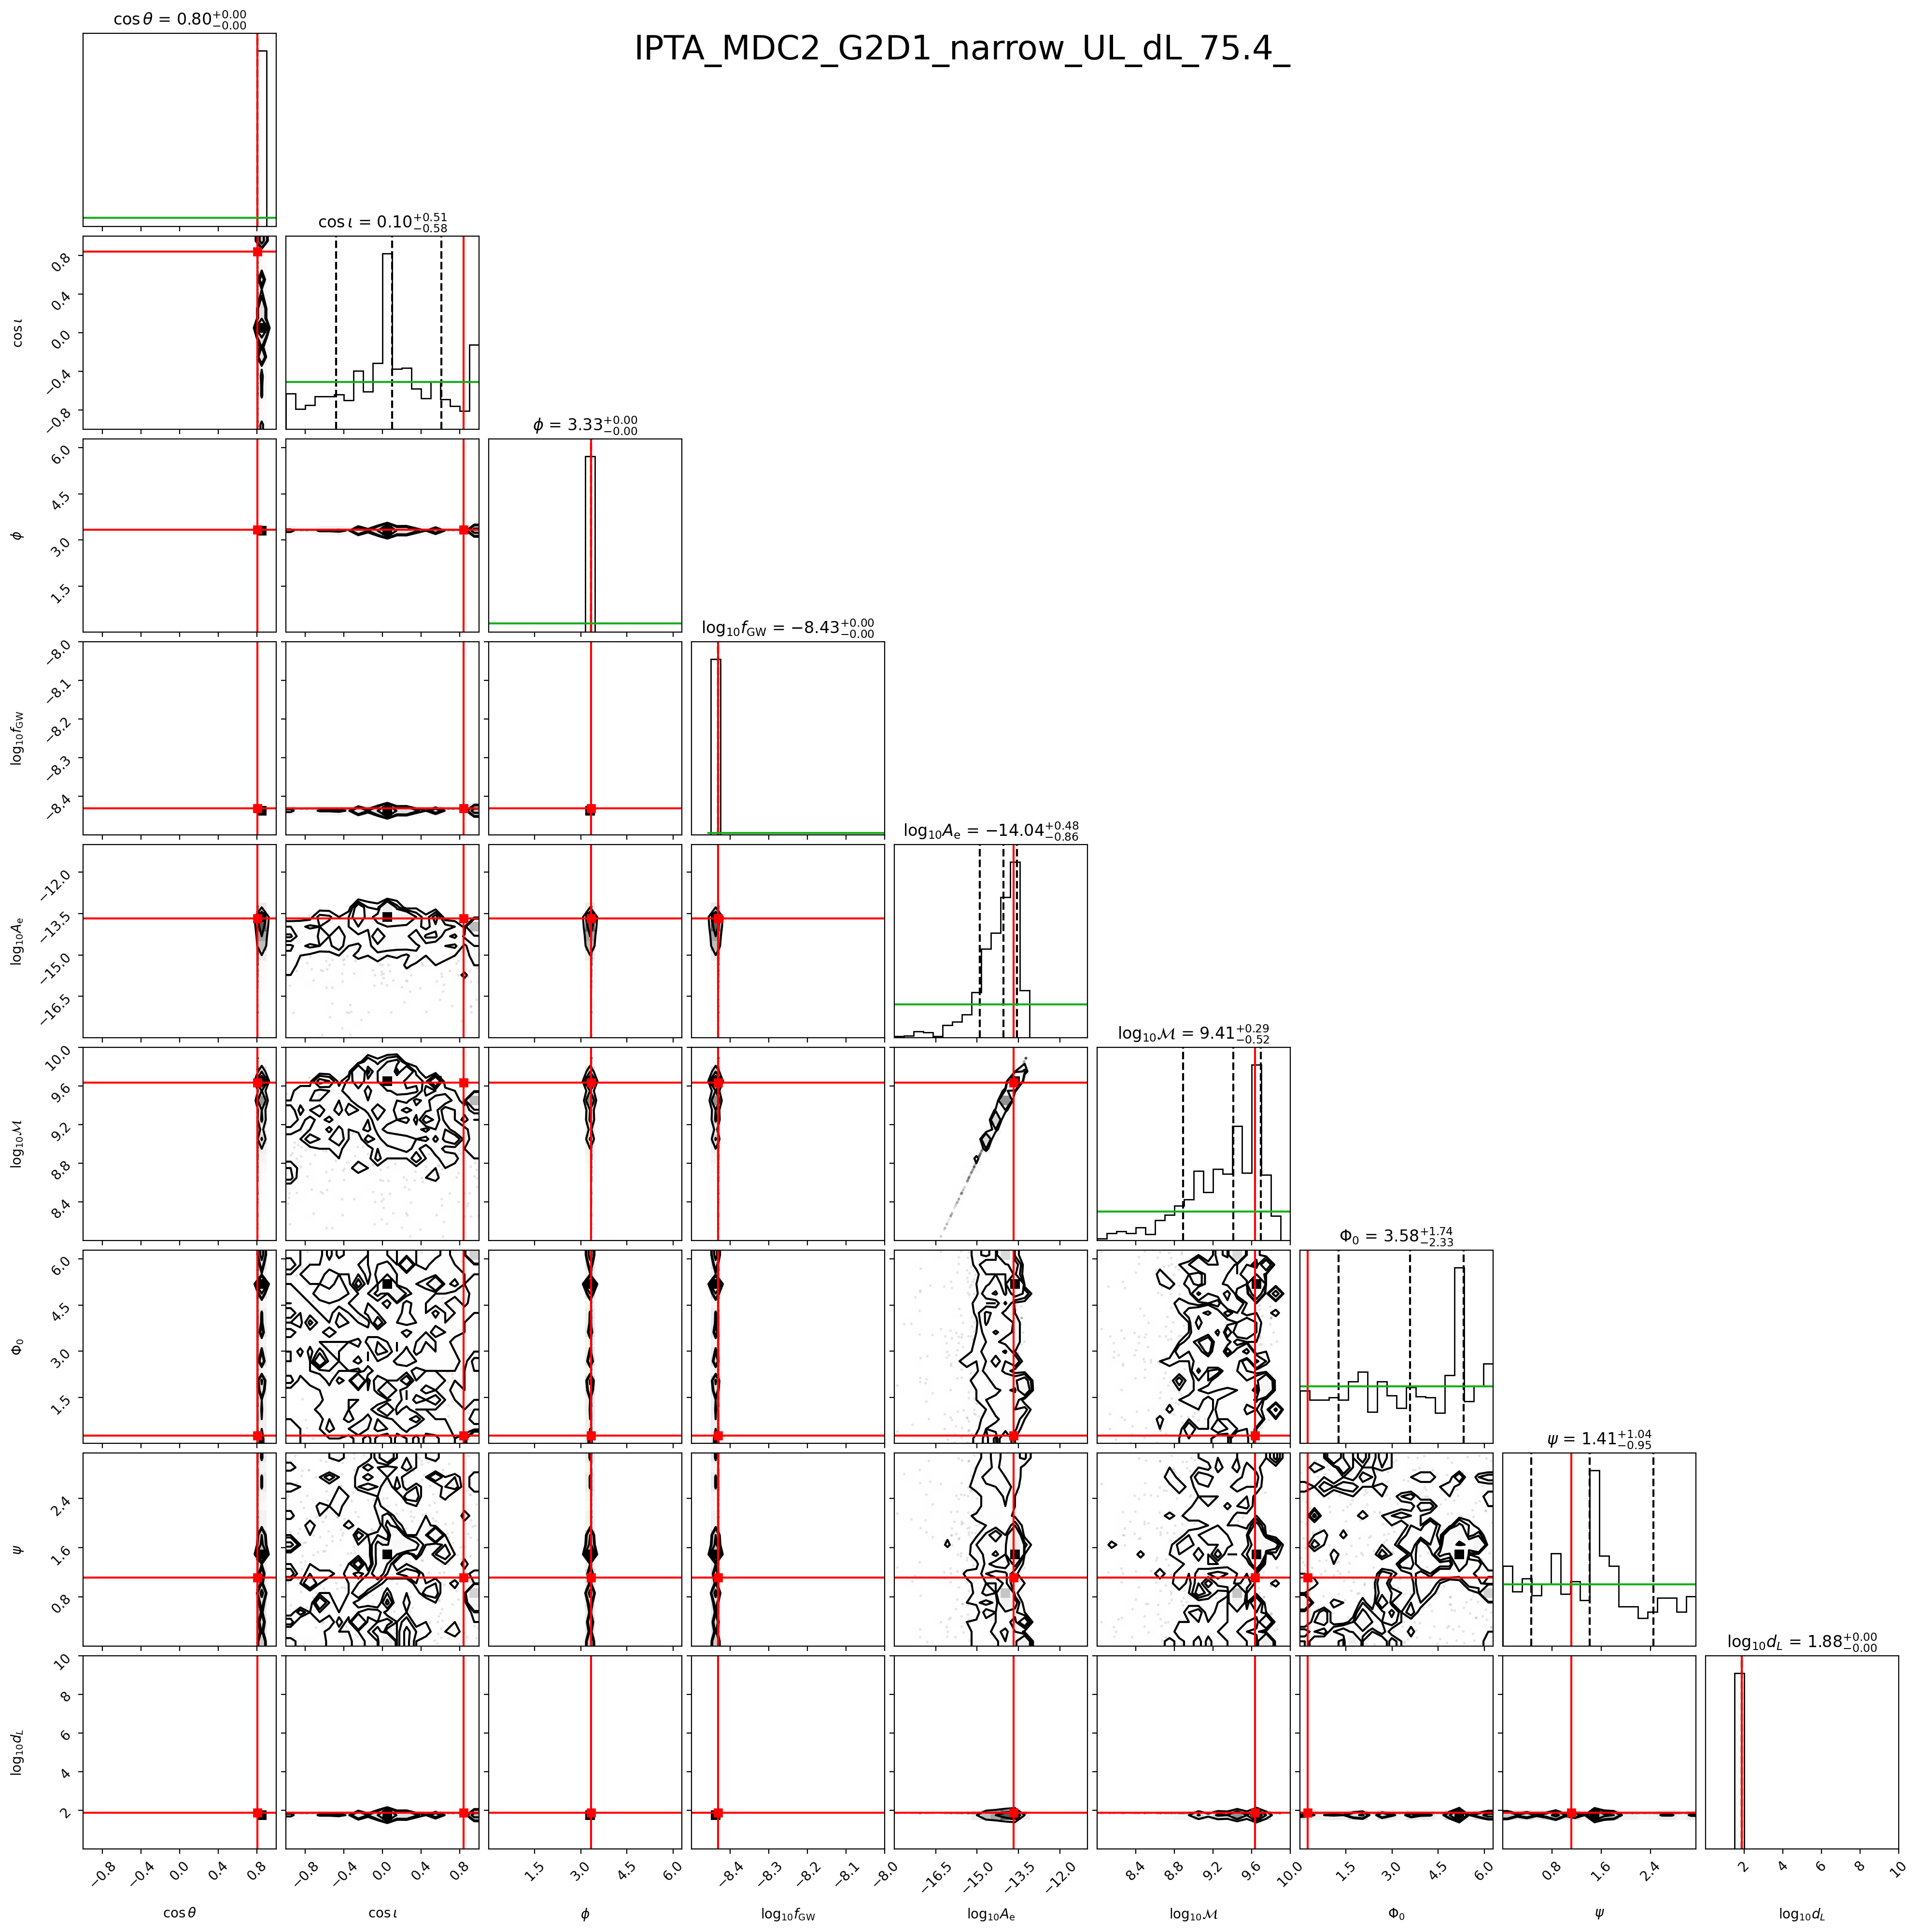

In [9]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
          r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
          
# Mapping from pretty labels → xxx0 keys
label_to_key = {
    r"$\cos \theta$": "0_cos_gwtheta",
    r"$\cos \iota$": "0_cos_inc",
    r"$\phi$": "0_gwphi",
    r"$\log_{10} f_{\rm GW}$": "0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi",
    r"$\log_{10} d_L$": "distance"
}

# Build truths list (log-transform distance for d_L)
truths = []
for lab in labels:
    key = label_to_key[lab]
    if lab == r"$\log_{10} d_L$":
        truths.append(np.log10(xxx0[key]))
    else:
        truths.append(xxx0[key])
        
#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.5,-8), (-18,-11), (8,10), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################
target_d_L = 75.4#Mpc
d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

#fig = corner.corner(samples2plot[d_L_mask, :],
 #                   labels=labels,
  #                  show_titles=True, quantiles=[0.16, 0.5, 0.84],
   #                 range=ranges, hist_kwargs={"density":True})

fig = corner.corner(
    samples2plot[d_L_mask, :],   # <-- use samples2plot, not samples2plot_detect
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0 or i==(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==2*(len(labels)+1) or i==6*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_fgw
        Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==4*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==5*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(7.84, 10.26)
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==7*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
fig.suptitle(crnr_plt_title2, fontsize = 25);

## Trace Plots

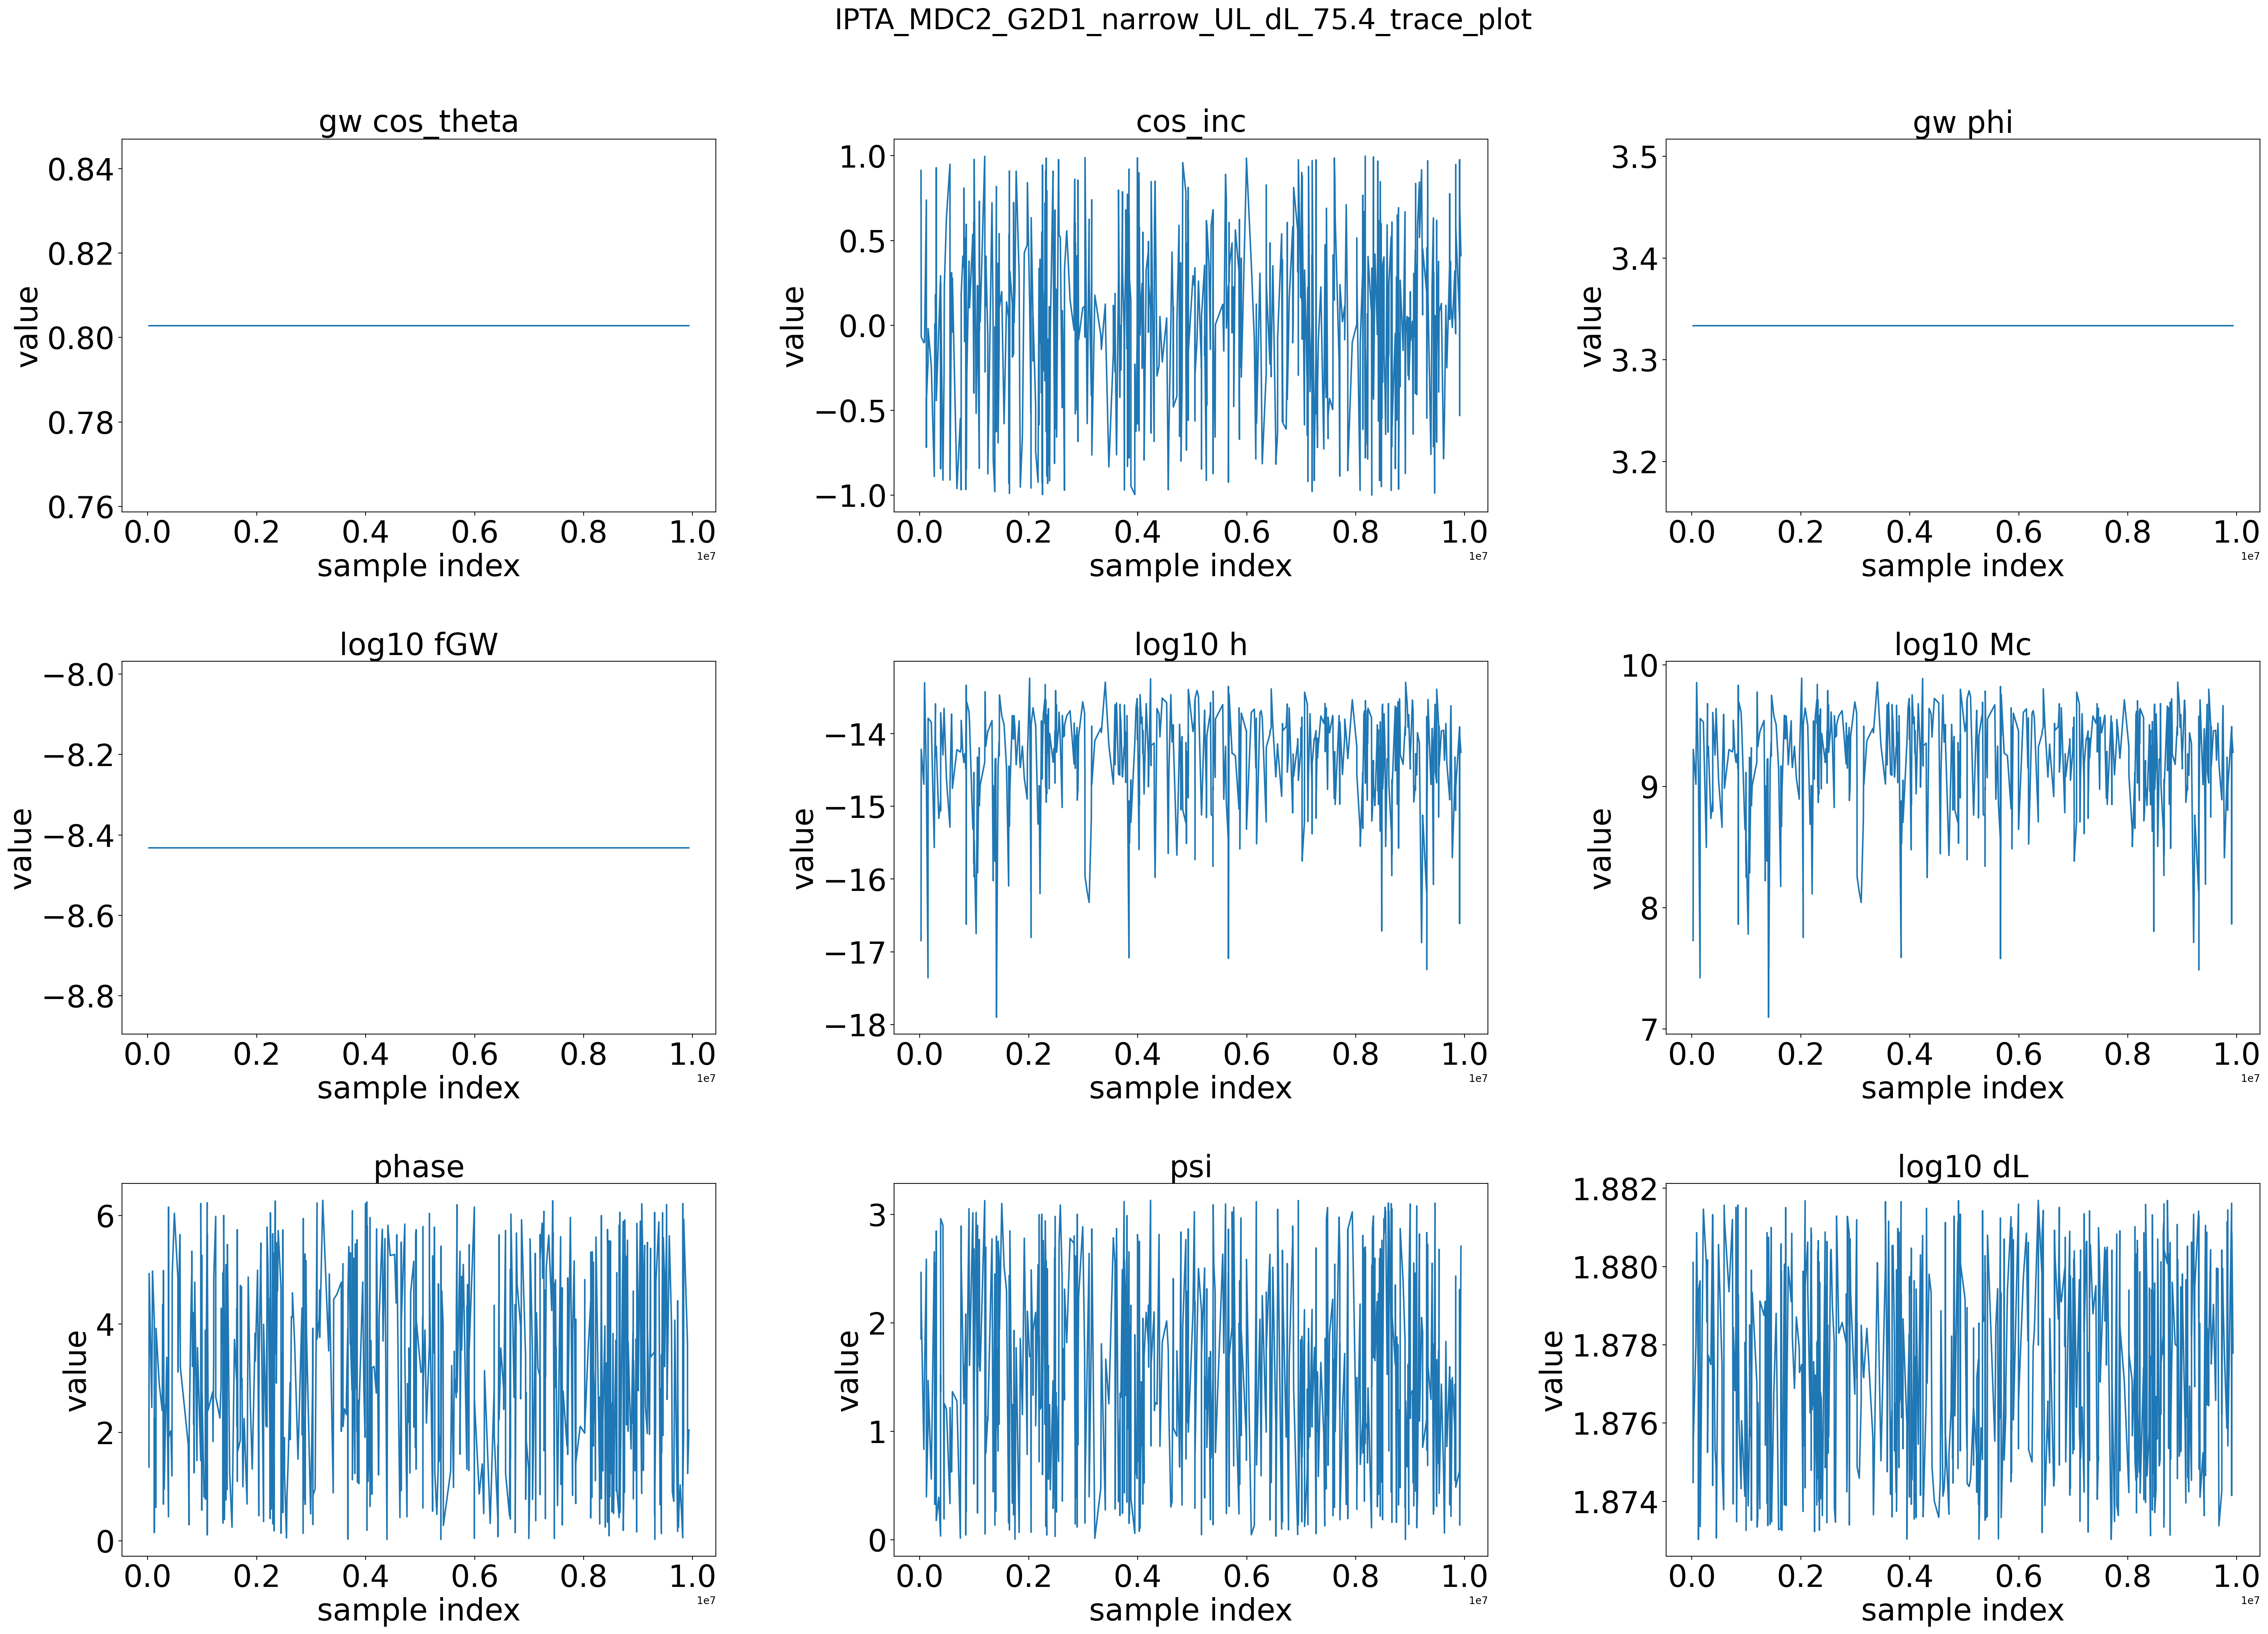

In [10]:
import matplotlib.pyplot as plt

title = ["gw cos_theta", "cos_inc", "gw phi", "log10 fGW", 
         "log10 h", "log10 Mc", "phase", "psi", "log10 dL"]

j = -1
row, column = 3, 3
fig, axs = plt.subplots(row, column, figsize=(30, 20))
fig.tight_layout(h_pad=3, w_pad=2)

# Loop over parameters
for i in range(len(title)): 
    if i % column == 0:
        j += 1
    axs[j, i % column].plot(d_L_mask, samples2plot[d_L_mask, i])
    axs[j, i % column].set_title(title[i], fontsize=30)    # bigger subplot title
    axs[j, i % column].tick_params(axis="both", labelsize=30)  # bigger tick labels
    axs[j, i % column].set_xlabel("sample index", fontsize=30)
    axs[j, i % column].set_ylabel("value", fontsize=30)

# Global title
fig.suptitle(trace_plot_title, fontsize=28, y=1.08)

plt.subplots_adjust(hspace=0.4, wspace=0.3)  # more spacing
#plt.show()
#plt.savefig("trace_plots.png", dpi=200, bbox_inches="tight")


In [11]:
print(samples2plot[d_L_mask,5])

[7.7283826 7.7283826 9.304367  9.017189  9.855797  9.855797  9.068758
 9.068758  9.068758  9.068758  7.421757  9.558416  9.531468  8.496575
 9.229977  9.681785  9.2494955 9.328799  9.328799  9.328799  8.73532
 8.874565  8.874565  8.874565  8.794874  9.608226  9.257577  9.641512
 9.567928  9.063717  8.663035  9.014481  9.59321   9.341112  8.984941
 9.303045  9.284424  9.32251   9.543649  9.265042  9.199305  9.199305
 9.265058  9.168854  9.146803  9.267061  9.833021  7.863262  9.514936
 9.514936  9.514936  9.692185  9.611499  9.514356  8.6514    8.6514
 8.629644  8.629644  8.366679  9.115072  8.285771  8.250965  8.555477
 7.781887  9.239518  8.927919  8.927919  8.286179  9.317882  8.9684105
 8.9684105 8.965533  8.965533  8.841163  8.841163  9.008085  9.199117
 9.776827  9.776827  9.776827  9.776827  9.776827  9.776827  9.776827
 9.776827  9.776827  9.776827  9.776827  9.776827  9.776827  9.776827
 9.776827  9.776827  9.776827  9.776827  9.776827  9.776827  9.776827
 9.776827  9.776827  9

## Upper Limit


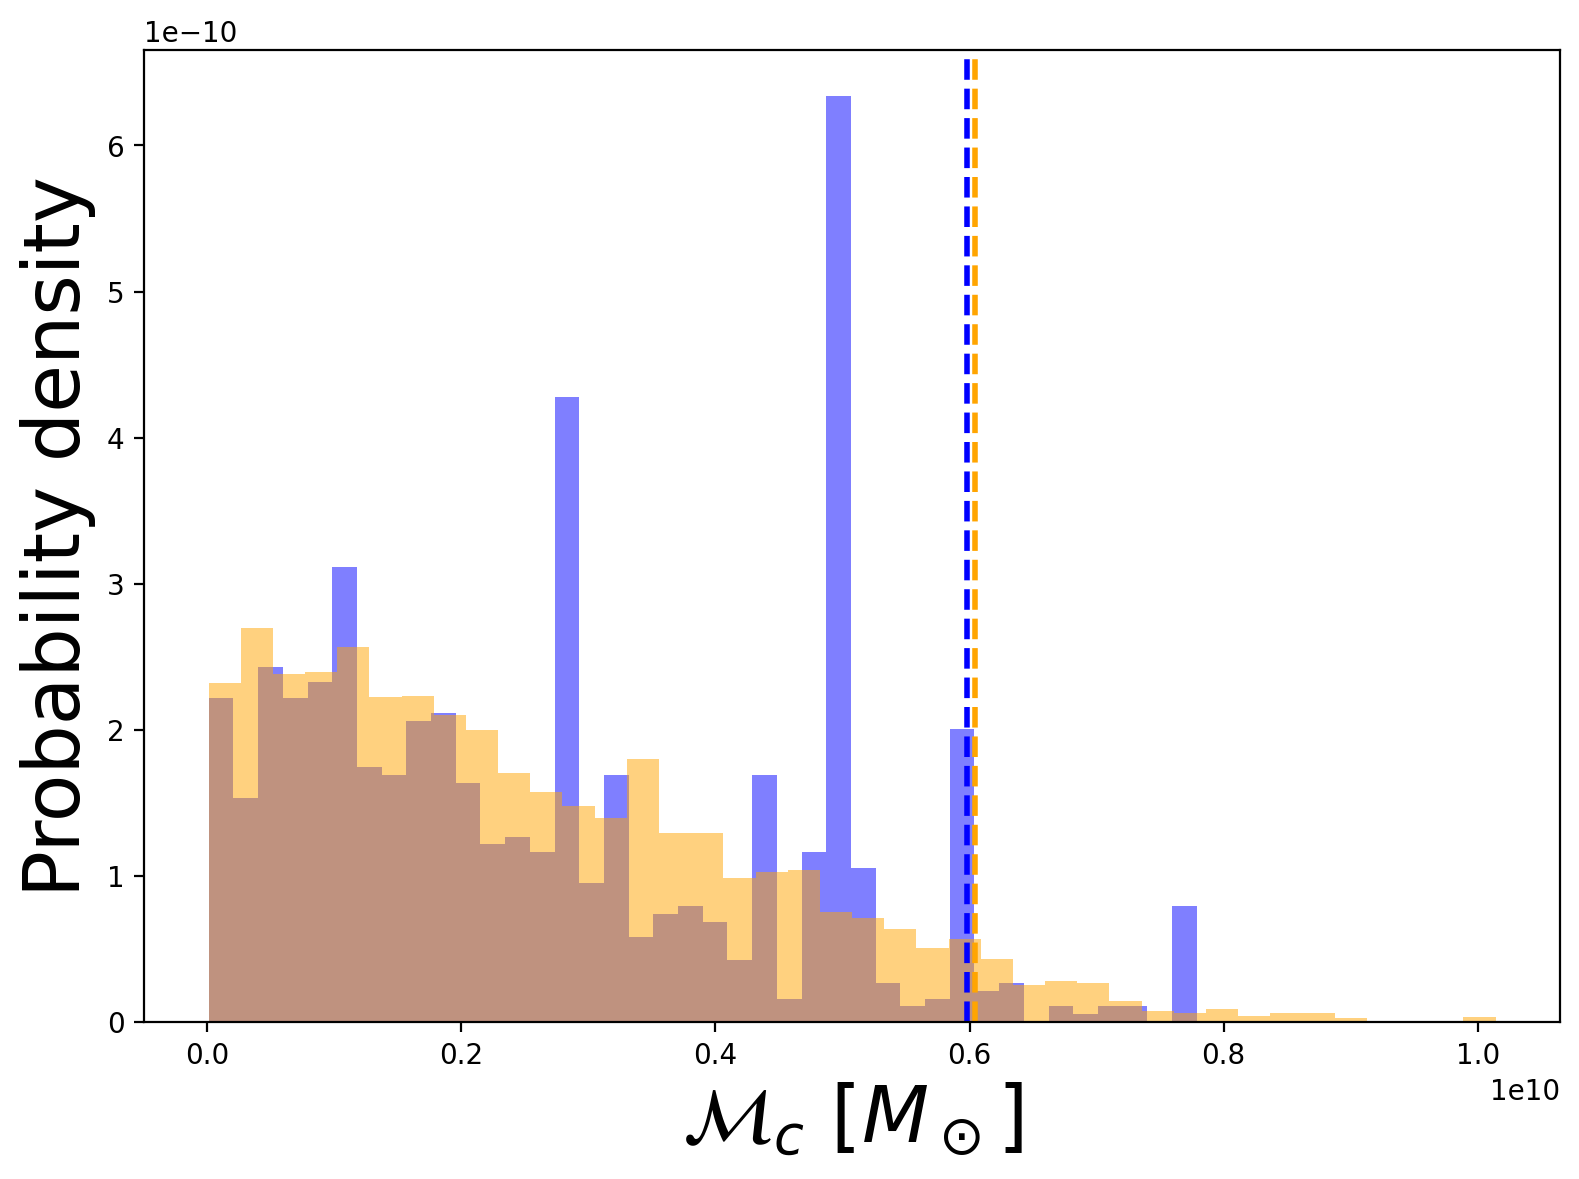

QuickCW 95% UL Mc      = 5.9817e+09, log10 = 9.7768
Enterprise 95% UL Mc   = 6.0445e+09, log10 = 9.7814


In [16]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# ============================================================
# 1. QUICKCW chirp mass samples (linear scale)
# ============================================================
qc_mc = 10**samples2plot[d_L_mask, 5]       # column 5 = log10 Mc
qc_ul = np.quantile(qc_mc, 0.95)

# ============================================================
# 2. ENTERPRISE chirp mass samples (from .h5)
# ============================================================
enterprise_file = "/scratch/na00078/projects/IPTA_MDC2/h5_files/core_single_MDC2_DS1.h5"

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]
idx_log10_mc = e_params.index("log10_mc")

mc_ent = 10**(e_samples[:, idx_log10_mc])
ent_ul = np.quantile(mc_ent, 0.95)

# ============================================================
# 3. Plot posteriors
# ============================================================
plt.figure(figsize=(8,6))

bins = 40

plt.hist(
    qc_mc, bins=bins, density=True,
    color="blue", alpha=0.5, label="QuickCW posterior"
)

plt.hist(
    mc_ent, bins=bins, density=True,
    color="orange", alpha=0.5, label="Enterprise posterior"
)

# ============================================================
# 4. Plot ULs
# ============================================================
plt.axvline(
    qc_ul, color="blue", linestyle="--", linewidth=2,
    label=f"QuickCW 95% UL = {qc_ul:.2e}"
)

plt.axvline(
    ent_ul, color="orange", linestyle="--", linewidth=2,
    label=f"Enterprise 95% UL = {ent_ul:.2e}"
)

# ============================================================
# 5. Labels + formatting
# ============================================================
plt.xlabel(r"$\mathcal{M}_c \,\, [M_\odot]$",fontsize=28)
plt.ylabel("Probability density",fontsize=28)
#plt.title("Chirp Mass Posteriors and 95% Upper Limits")
#plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6. Print numeric ULs
# ============================================================
print("QuickCW 95% UL Mc      = {:.4e}, log10 = {:.4f}".format(qc_ul, np.log10(qc_ul)))
print("Enterprise 95% UL Mc   = {:.4e}, log10 = {:.4f}".format(ent_ul, np.log10(ent_ul)))


In [17]:
import numpy as np
import h5py
from scipy.stats import gaussian_kde

# ============================================================
# Helper: convert linear → log10 with error propagation
# ============================================================
def linear_to_log10(UL, UL_err):
    logUL = np.log10(UL)
    logUL_err = UL_err / (UL * np.log(10))
    return logUL, logUL_err

# ============================================================
# 1. QUICKCW: Chirp Mass UL
# ============================================================
qc_mc = 10**samples2plot[d_L_mask, 5]
N_qc = len(qc_mc)
q = 0.95

qc_mc_UL = np.quantile(qc_mc, q)
kde_qc_mc = gaussian_kde(qc_mc)
f_q_qc_mc = kde_qc_mc.evaluate([qc_mc_UL])[0]
qc_mc_UL_err = np.sqrt(q*(1-q)) / (f_q_qc_mc * np.sqrt(N_qc))

qc_mc_logUL, qc_mc_logUL_err = linear_to_log10(qc_mc_UL, qc_mc_UL_err)

print("QUICKCW Mc:")
print(f"  95% UL = {qc_mc_UL:.3e} ± {qc_mc_UL_err:.1e}")
print(f"  log10 UL = {qc_mc_logUL:.3f} ± {qc_mc_logUL_err:.4f}")

# ============================================================
# 2. ENTERPRISE: Chirp Mass UL
# ============================================================
enterprise_file = "/scratch/na00078/projects/IPTA_MDC2/h5_files/core_single_MDC2_DS1_varyfgw.h5"

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]
idx_log10_mc = e_params.index("log10_mc")

ent_mc = 10**(e_samples[:, idx_log10_mc])
N_ent = len(ent_mc)

ent_mc_UL = np.quantile(ent_mc, q)
kde_ent_mc = gaussian_kde(ent_mc)
f_q_ent_mc = kde_ent_mc.evaluate([ent_mc_UL])[0]
ent_mc_UL_err = np.sqrt(q*(1-q)) / (f_q_ent_mc * np.sqrt(N_ent))

ent_mc_logUL, ent_mc_logUL_err = linear_to_log10(ent_mc_UL, ent_mc_UL_err)

print("\nENTERPRISE Mc:")
print(f"  95% UL = {ent_mc_UL:.3e} ± {ent_mc_UL_err:.1e}")
print(f"  log10 UL = {ent_mc_logUL:.3f} ± {ent_mc_logUL_err:.4f}")

# ============================================================
# 3. QUICKCW: h (strain amplitude) UL
# ============================================================
qc_h = 10**samples2plot[d_L_mask, 4]
qc_h_UL = np.quantile(qc_h, q)

kde_qc_h = gaussian_kde(qc_h)
f_q_qc_h = kde_qc_h.evaluate([qc_h_UL])[0]
qc_h_UL_err = np.sqrt(q*(1-q)) / (f_q_qc_h * np.sqrt(N_qc))

qc_h_logUL, qc_h_logUL_err = linear_to_log10(qc_h_UL, qc_h_UL_err)

print("\nQUICKCW h:")
print(f"  95% UL = {qc_h_UL:.3e} ± {qc_h_UL_err:.1e}")
print(f"  log10 UL = {qc_h_logUL:.3f} ± {qc_h_logUL_err:.4f}")

# ============================================================
# 4. ENTERPRISE: h UL (must compute h(m_c))
# ============================================================
# Fixed frequency for this dataset
f = 3.7e-9  # Hz

# Distance
D_MPC = 75.400
MPC2M = 3.085677581491367e22
dL = D_MPC * MPC2M

# Constants
G = 6.67430e-11
c = 2.99792458e8
M_sun = 1.98840987e30

mc_solar_ent = ent_mc
mc_si_ent = mc_solar_ent * M_sun * G / c**3  # seconds

# Compute h for enterprise samples
h_ent = 2 * mc_si_ent**(5/3) * (np.pi * f)**(2/3) / dL

ent_h_UL = np.quantile(h_ent, q)

kde_ent_h = gaussian_kde(h_ent)
f_q_ent_h = kde_ent_h.evaluate([ent_h_UL])[0]
ent_h_UL_err = np.sqrt(q*(1-q)) / (f_q_ent_h * np.sqrt(N_ent))

ent_h_logUL, ent_h_logUL_err = linear_to_log10(ent_h_UL, ent_h_UL_err)

print("\nENTERPRISE h:")
print(f"  95% UL = {ent_h_UL:.3e} ± {ent_h_UL_err:.1e}")
print(f"  log10 UL = {ent_h_logUL:.3f} ± {ent_h_logUL_err:.4f}")


QUICKCW Mc:
  95% UL = 5.982e+09 ± 1.2e+08
  log10 UL = 9.777 ± 0.0085

ENTERPRISE Mc:
  95% UL = 6.292e+09 ± 6.0e+06
  log10 UL = 9.799 ± 0.0004

QUICKCW h:
  95% UL = 3.751e-14 ± 1.1e-15
  log10 UL = -13.426 ± 0.0129

ENTERPRISE h:
  95% UL = 1.349e-22 ± 1.9e-25
  log10 UL = -21.870 ± 0.0006


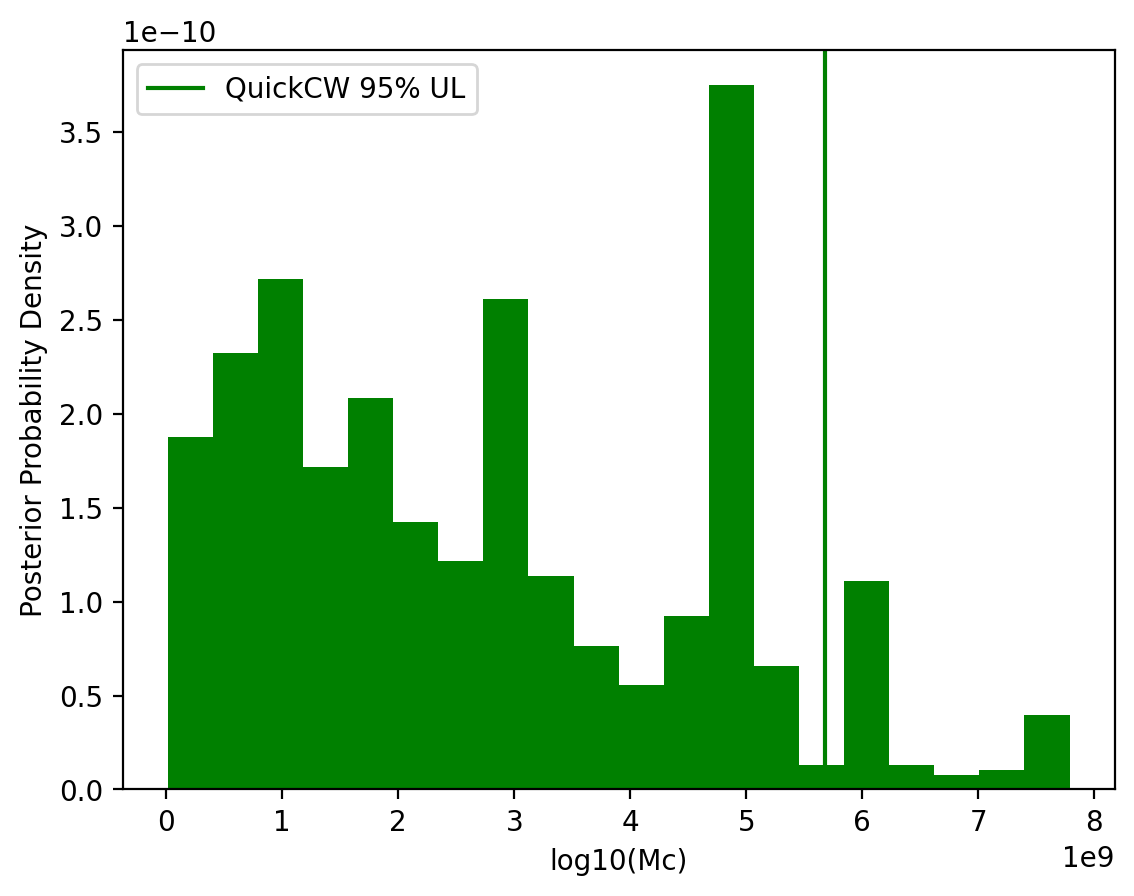

95% Chirp Mass Upper Limit = 5.98173e+09
95% Chirp Mass Upper Limit log10 = 9.77683
95% Chirp Mass Upper Limit Error = 6.29662e+07
95% Chirp Mass Upper Limit Error log10 = 7.79911


In [12]:
#dL Mc Upper limit

logMcmin_dL = np.min(samples2plot[d_L_mask,5])
logMcmax_dL = np.max(samples2plot[d_L_mask,5])

#print(samples2plot[d_L_mask,5])
#print(np.power(10,samples2plot[d_L_mask,5]))

bins=20

counts, bin_edges, _ = plt.hist(np.power(10, samples2plot[d_L_mask,5]), bins=bins, density=True, color='green')

plt.axvline(x = 5.68214e+09,color='green',label= "QuickCW 95% UL")
#plt.axvline(x = 1.34e+09,color='red',label= "12.5yr Upper Limit = 1.34e+09 ")
#plt.title("NGC3115 Upper Limit without J1713 Mc histogram (with dL masking)", y=1.05)
plt.xlabel("log10(Mc)")
plt.ylabel("Posterior Probability Density")
plt.legend()
plt.show()
 
x = np.quantile(np.power(10,samples2plot[d_L_mask,5]), 0.95)

print("95% Chirp Mass Upper Limit = {:0.5e}".format(x))
print("95% Chirp Mass Upper Limit log10 = {:0.5f}".format(np.log10(x)))

#bin_index = np.digitize(np.log10(x), bin_edges) -1
bin_index = np.digitize(x, bin_edges) - 1 

y_value=counts[bin_index]

sigma = np.sqrt((.95*.05)/len(d_L_mask))/y_value
print("95% Chirp Mass Upper Limit Error = {:0.5e}".format(sigma))
print("95% Chirp Mass Upper Limit Error log10 = {:0.5f}".format(np.log10(sigma)))

In [13]:
import numpy as np
from scipy.stats import gaussian_kde

# Number of samples
N = len(d_L_mask)

# Chirp mass in linear scale
mc_samples = np.power(10, samples2plot[d_L_mask,5])

# Confidence level
q = 0.95

# Upper limit = quantile
UL = np.quantile(mc_samples, q)

# Estimate PDF at UL
kde = gaussian_kde(mc_samples)
f_q = kde.evaluate([UL])[0]

# Analytic error estimate
UL_err = np.sqrt(q*(1-q)) / (f_q * np.sqrt(N))

print(f"95% UL (Mc) = {UL:.3e} ± {UL_err:.1e}")


95% UL (Mc) = 5.982e+09 ± 1.2e+08


In [14]:
import numpy as np

def linear_to_log10(UL, UL_err):
    """
    Convert an upper limit and its error from linear scale to log10 scale.

    Parameters
    ----------
    UL : float
        Upper limit in linear scale.
    UL_err : float
        Error on UL in linear scale.

    Returns
    -------
    logUL : float
        log10(UL).
    logUL_err : float
        Error on log10(UL).
    """
    logUL = np.log10(UL)
    logUL_err = UL_err / (UL * np.log(10))
    return logUL, logUL_err



logUL, logUL_err = linear_to_log10(UL, UL_err)
print(f"log10 UL = {logUL:.3f} ± {logUL_err:.4f}")


log10 UL = 9.777 ± 0.0085


In [15]:
import numpy as np
from scipy.stats import gaussian_kde

# ---------------------------------------------------
# Extract strain samples (linear)
# ---------------------------------------------------
h_samples = np.power(10, samples2plot[d_L_mask, 4])
N = len(h_samples)

# Confidence level
q = 0.95

# ---------------------------------------------------
# Compute h upper limit
# ---------------------------------------------------
h_UL = np.quantile(h_samples, q)

# ---------------------------------------------------
# Build KDE for error estimate
# ---------------------------------------------------
kde = gaussian_kde(h_samples)
f_q = kde.evaluate([h_UL])[0]      # evaluate at the UL

# ---------------------------------------------------
# Analytic uncertainty
# ---------------------------------------------------
h_UL_err = np.sqrt(q * (1 - q)) / (f_q * np.sqrt(N))

print(f"95% UL (h) = {h_UL:.3e} ± {h_UL_err:.1e}")


# ---------------------------------------------------
# Convert to log10
# ---------------------------------------------------
def linear_to_log10(h_UL, h_UL_err):
    h_logUL = np.log10(h_UL)
    h_logUL_err = h_UL_err / (h_UL * np.log(10))
    return h_logUL, h_logUL_err

h_logUL, h_logUL_err = linear_to_log10(h_UL, h_UL_err)
print(f"log10 UL = {h_logUL:.3f} ± {h_logUL_err:.4f}")


95% UL (h) = 3.751e-14 ± 1.1e-15
log10 UL = -13.426 ± 0.0129
